# 🏭 Fase 2 — Comprensión de los Datos
### Trabajo Final · Minería de Datos · UNMSM-FISI · 2026-I
**Dataset:** Notificaciones de Accidentes de Trabajo no Mortales — MTPE, Sistema SAT (datosabiertos.gob.pe)

**Problema:** ¿bajo qué condiciones laborales un accidente de trabajo deja al trabajador con una **secuela permanente**?

---
### Estructura de esta fase (CRISP-DM)
**4 etapas** + auditoría de las **8 dimensiones de calidad**:
1. **Recopilación** de datos iniciales
2. **Descripción** (cantidad, tipos, codificación, dimensiones)
3. **Exploración (EDA)** — univariado, bivariado, outliers, faltantes, categóricas
4. **Verificación de calidad** — Exactitud · Completitud · Consistencia · Integridad · Razonabilidad · Oportunidad · Unicidad · Validez

> ⚠️ Este notebook **detecta** problemas; **no los corrige**. La limpieza es la Fase 3 (Preparación).


## ⚙️ Setup

pip install pandas numpy matplotlib seaborn
```


In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paleta institucional UNMSM
GRANATE, DORADO, AZUL, GRIS, VERDE = "#7a1128", "#d4a72c", "#3b6ea5", "#6b6b6b", "#2e7d5b"
sns.set_theme(style="whitegrid", context="notebook", palette=[GRANATE, DORADO, AZUL, VERDE, GRIS])
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": GRANATE,
    "axes.labelsize": 11, "axes.grid": True, "grid.color": "#eee",
    "font.size": 10, "legend.frameon": False,
})
print("Entorno listo ✓")


Entorno listo ✓


---
## 🗂️ Etapa 1 — Recopilación de datos iniciales

**Fuente:** *Flat file* (CSV) de la **Plataforma Nacional de Datos Abiertos**, entidad **MTPE**
(Sistema de Accidentes de Trabajo — SAT). Único origen → sin riesgos de *join*.

⚠️ **Primer hallazgo de calidad, antes incluso de leer los datos:** el archivo **NO está en UTF-8**,
viene en **latin-1**. Si se lee mal, los encabezados se corrompen (`REGIÓN` → `REGIÎ`).


In [3]:
RUTA = "../data set/Dataset__Noti_AT_No_Mort_SAT_0.csv"
# Demostración del problema de codificación
print("❌ Leído como UTF-8 (o mal detectado):")
try:
    mal = pd.read_csv(RUTA, sep=';', encoding='utf-8', nrows=1)
    print("  ", list(mal.columns))
except Exception as e:
    print("   Falla al leer:", type(e).__name__)

print("\n✅ Leído correctamente como latin-1:")
df = pd.read_csv(RUTA, sep=';', encoding='latin-1')
df.columns = [c.strip() for c in df.columns]
print("  ", list(df.columns))
print(f"\nDimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")


❌ Leído como UTF-8 (o mal detectado):
   Falla al leer: UnicodeDecodeError

✅ Leído correctamente como latin-1:
   ['FECHA_CORTE', 'ANIOS', 'MES', 'REGIÎ', 'ACTIVIDAD_ECONÍICA', 'SEXO', 'CATEGORA_OCUPACIONAL', 'FORMA_DEL_ACCIDENTE', 'AGENTE_CAUSANTE', 'PARTE_DEL_CUERPO_LESIONADA', 'NATURALEZA_DE_LA_LESIÎ', 'ACCIDENTE_LEVE', 'ACCIDENTE_INCAPACITANTE', 'ACCIDENTE_MORTAL']

Dimensiones: 276,646 filas × 14 columnas


In [4]:
# Los nombres siguen corruptos porque el archivo se GUARDÓ con la codificación equivocada.
# Documentamos el mapeo (la corrección se aplica en Fase 3).
RENOMBRAR = {
    "REGIÎ": "REGION",
    "ACTIVIDAD_ECONÍICA": "ACTIVIDAD_ECONOMICA",
    "CATEGORA_OCUPACIONAL": "CATEGORIA_OCUPACIONAL",
    "NATURALEZA_DE_LA_LESIÎ": "NATURALEZA_DE_LA_LESION",
}
df = df.rename(columns=RENOMBRAR)
print("Columnas normalizadas:")
for c in df.columns: print("  ·", c)


Columnas normalizadas:
  · FECHA_CORTE
  · ANIOS
  · MES
  · REGION
  · ACTIVIDAD_ECONOMICA
  · SEXO
  · CATEGORIA_OCUPACIONAL
  · FORMA_DEL_ACCIDENTE
  · AGENTE_CAUSANTE
  · PARTE_DEL_CUERPO_LESIONADA
  · NATURALEZA_DE_LA_LESION
  · ACCIDENTE_LEVE
  · ACCIDENTE_INCAPACITANTE
  · ACCIDENTE_MORTAL


---
## 📋 Etapa 2 — Descripción de los datos

In [5]:
def tipo_semantico(s):
    if pd.api.types.is_numeric_dtype(s):
        return "numérica (discreta)"
    return "categórica (nominal)"

resumen = pd.DataFrame({
    "tipo": [tipo_semantico(df[c]) for c in df.columns],
    "n_únicos": df.nunique().values,
    "%_nulos": (df.isna().mean().values * 100).round(1),
})
resumen.index = df.columns
print(f"{df.shape[0]:,} filas × {df.shape[1]} columnas\n")
display(resumen.style.background_gradient(subset=["n_únicos"], cmap="OrRd")
                     .format({"%_nulos": "{:.1f}%"}))


276,646 filas × 14 columnas



,tipo,n_únicos,%_nulos
FECHA_CORTE,numérica (discreta),1,0.0%
ANIOS,numérica (discreta),13,0.0%
MES,categórica (nominal),24,0.0%
REGION,categórica (nominal),28,0.0%
ACTIVIDAD_ECONOMICA,categórica (nominal),25,0.0%
SEXO,categórica (nominal),4,0.0%
CATEGORIA_OCUPACIONAL,categórica (nominal),13,27.5%
FORMA_DEL_ACCIDENTE,categórica (nominal),41,0.0%
AGENTE_CAUSANTE,categórica (nominal),49,2.9%
PARTE_DEL_CUERPO_LESIONADA,categórica (nominal),66,0.0%


In [6]:
# Cobertura temporal
print("Años:", sorted(df['ANIOS'].dropna().unique().astype(int)))
print("Periodos (año-mes) con datos:", df.groupby(['ANIOS','MES']).ngroups)
print("\nFECHA_CORTE (valores únicos):", df['FECHA_CORTE'].unique())
print("→ constante: columna SIN VARIANZA, se descartará en Fase 3.")


Años: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Periodos (año-mes) con datos: 142

FECHA_CORTE (valores únicos): [20240718.       nan]
→ constante: columna SIN VARIANZA, se descartará en Fase 3.


### 🎯 La variable objetivo: severidad
El MTPE ya clasifica la severidad — **no hay que inventar ningún umbral**.

In [7]:
for c in ['ACCIDENTE_LEVE', 'ACCIDENTE_INCAPACITANTE', 'ACCIDENTE_MORTAL']:
    print(f"\n{c}")
    vc = df[c].value_counts(dropna=False)
    for k, v in vc.items():
        print(f"   {str(k):<22} {v:>8,}  ({100*v/len(df):5.2f}%)")



ACCIDENTE_LEVE
   SI                      139,504  (50.43%)
   NO                      137,141  (49.57%)
   nan                           1  ( 0.00%)

ACCIDENTE_INCAPACITANTE
   nan                     139,582  (50.46%)
   TOTAL TEMPORAL          105,632  (38.18%)
   PARCIAL PERMANENTE       24,344  ( 8.80%)
   PARCIAL TEMPORAL          6,634  ( 2.40%)
   TOTAL PERMANENTE            454  ( 0.16%)

ACCIDENTE_MORTAL
   NO                      276,568  (99.97%)
   SI                           77  ( 0.03%)
   nan                           1  ( 0.00%)


In [8]:
# TARGET del Panel 2: ¿el accidente deja SECUELA PERMANENTE?
PERMANENTES = ["PARCIAL PERMANENTE", "TOTAL PERMANENTE"]
df["PERMANENTE"] = df["ACCIDENTE_INCAPACITANTE"].isin(PERMANENTES).astype(int)

n1 = int(df["PERMANENTE"].sum()); n0 = len(df) - n1
print(f"Permanente (1) : {n1:>7,}  ({100*n1/len(df):.1f}%)   <- clase MINORITARIA")
print(f"No permanente(0): {n0:>7,}  ({100*n0/len(df):.1f}%)")
print(f"\nRatio de desbalance = 1 : {n0/n1:.0f}  -> justifica SMOTE / class_weight")


Permanente (1) :  24,798  (9.0%)   <- clase MINORITARIA
No permanente(0): 251,848  (91.0%)

Ratio de desbalance = 1 : 10  -> justifica SMOTE / class_weight


> **⚠️ Nota anti-*data leakage**
> `NATURALEZA_DE_LA_LESION` (ej. *amputación*) y `PARTE_DEL_CUERPO_LESIONADA` describen la
> **consecuencia**, no la causa. Usarlas para predecir la gravedad sería *hacer trampa*: el modelo
> acertaría casi siempre, pero no serviría para **prevenir** nada.
> → **Se excluyen del modelo a propósito.** Predecimos desde el **contexto laboral**
> (sector, región, forma del accidente, agente causante, ocupación).


---
## 🔍 Etapa 3 — Exploración (EDA)

### 3.1 · El problema de CONSISTENCIA (el hallazgo estrella)
*"La tabla mentía. En 3 lugares distintos."* — pero esta vez con datos reales.


In [9]:
print("MES — valores únicos:", df['MES'].nunique(), "(¡debería tener 12!)")
print(df['MES'].value_counts().to_string())


MES — valores únicos: 24 (¡debería tener 12!)
MES
NOVIEMBRE    21653
FEBRERO      21209
OCTUBRE      20953
MARZO        20703
MAYO         18868
ABRIL        18270
SETIEMBRE    18171
DICIEMBRE    18164
ENERO        17981
JULIO        17499
AGOSTO       17210
JUNIO        14867
Enero         6126
Febrero       5951
Marzo         5836
Abril         5825
Mayo          5572
Noviembre     3324
Octubre       3288
Julio         3280
Junio         3182
Agosto        3051
Setiembre     3007
Diciembre     2655


**Diagnóstico:** `NOVIEMBRE` y `Noviembre` son **el mismo mes**, escrito con distinta
capitalización. El dataset tiene **24 categorías donde deberían existir 12**. Un modelo trataría
`ENERO` y `Enero` como meses distintos. → **Dimensión: Consistencia (codificación).**


In [10]:
print("SEXO — valores únicos:", df['SEXO'].nunique(), "(¡debería tener 2!)")
print(df['SEXO'].value_counts(dropna=False).to_string())
print("\n→ HOMBRE = MASCULINO  y  MUJER = FEMENINO. Misma categoría, dos etiquetas.")


SEXO — valores únicos: 4 (¡debería tener 2!)
SEXO
HOMBRE       192013
MASCULINO     40175
MUJER         33535
FEMENINO      10922
NaN               1

→ HOMBRE = MASCULINO  y  MUJER = FEMENINO. Misma categoría, dos etiquetas.


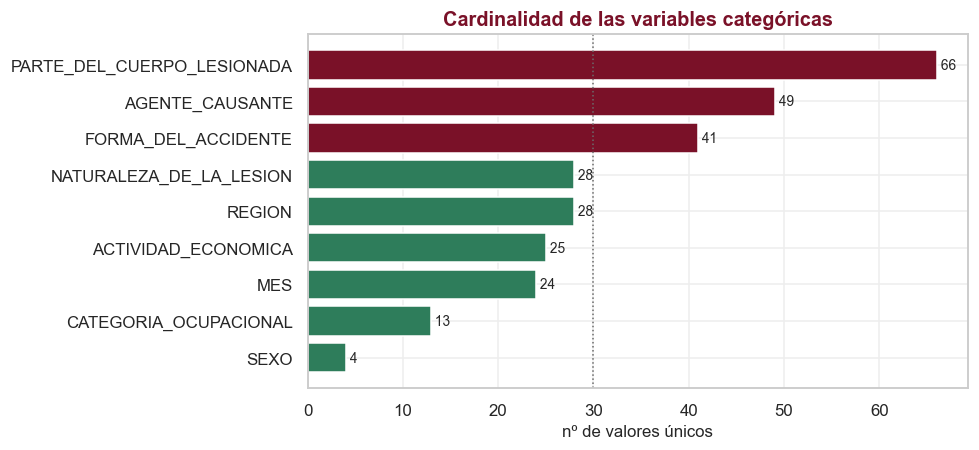

Rojo = cardinalidad alta -> requiere agrupación o codificación cuidadosa (Fase 3).


In [11]:
# Visualizamos la cardinalidad de todas las categóricas
cats = ['SEXO','MES','CATEGORIA_OCUPACIONAL','REGION','ACTIVIDAD_ECONOMICA',
        'NATURALEZA_DE_LA_LESION','FORMA_DEL_ACCIDENTE','AGENTE_CAUSANTE',
        'PARTE_DEL_CUERPO_LESIONADA']
card = pd.Series({c: df[c].nunique() for c in cats}).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.2))
colores = [VERDE if v <= 30 else GRANATE for v in card.values]
bars = ax.barh(card.index, card.values, color=colores)
ax.set_title("Cardinalidad de las variables categóricas")
ax.set_xlabel("nº de valores únicos")
for b, v in zip(bars, card.values):
    ax.text(v, b.get_y()+b.get_height()/2, f" {v}", va="center", fontsize=9)
ax.axvline(30, color=GRIS, ls=":", lw=1)
plt.tight_layout(); plt.show()
print("Rojo = cardinalidad alta -> requiere agrupación o codificación cuidadosa (Fase 3).")


### 3.2 · Análisis univariado — categóricas clave

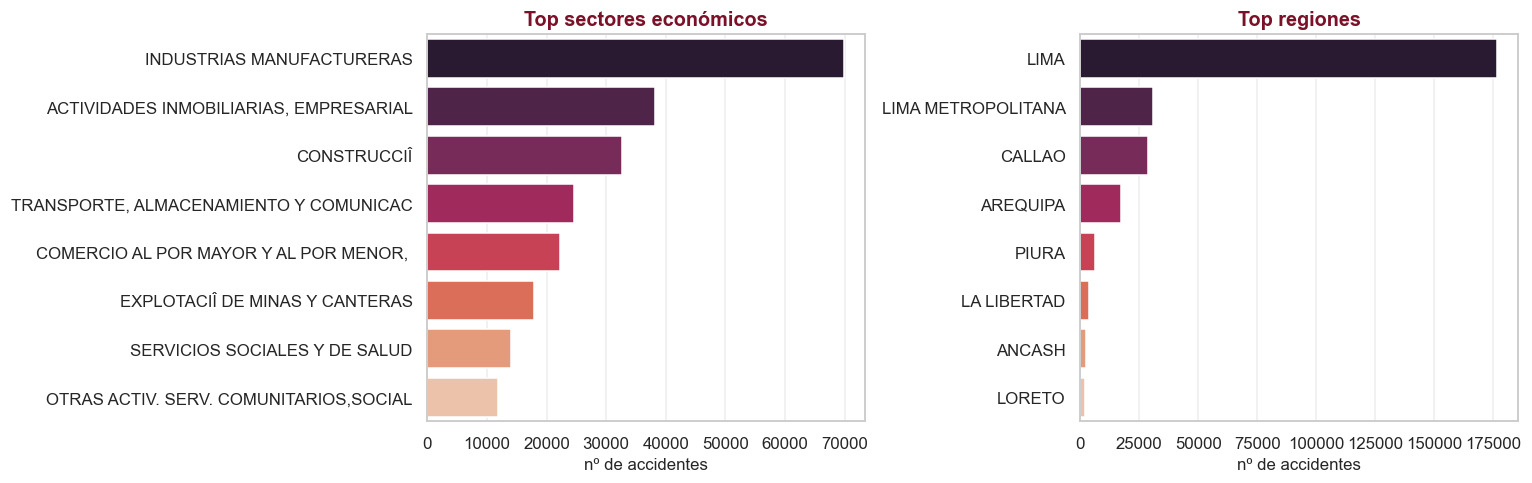

⚠️ Ojo: 'LIMA' y 'LIMA METROPOLITANA' conviven -> ¿son la misma región? (decisión de Fase 3)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, c, titulo in zip(axes,
                         ["ACTIVIDAD_ECONOMICA", "REGION"],
                         ["Top sectores económicos", "Top regiones"]):
    top = df[c].value_counts().head(8)
    sns.barplot(y=[t[:38] for t in top.index], x=top.values, ax=ax, palette="rocket")
    ax.set_title(titulo); ax.set_xlabel("nº de accidentes"); ax.set_ylabel("")
plt.tight_layout(); plt.show()
print("⚠️ Ojo: 'LIMA' y 'LIMA METROPOLITANA' conviven -> ¿son la misma región? (decisión de Fase 3)")


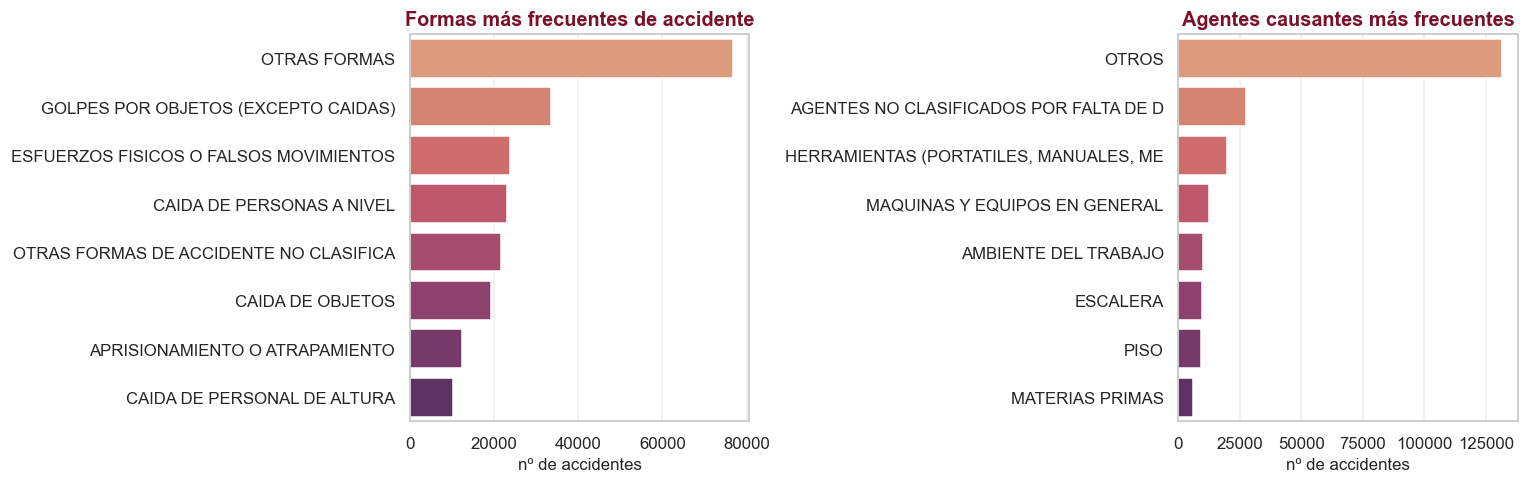

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, c, titulo in zip(axes,
                         ["FORMA_DEL_ACCIDENTE", "AGENTE_CAUSANTE"],
                         ["Formas más frecuentes de accidente", "Agentes causantes más frecuentes"]):
    top = df[c].value_counts().head(8)
    sns.barplot(y=[str(t)[:38] for t in top.index], x=top.values, ax=ax, palette="flare")
    ax.set_title(titulo); ax.set_xlabel("nº de accidentes"); ax.set_ylabel("")
plt.tight_layout(); plt.show()


### 3.3 · Desequilibrio de clases (la variable objetivo)

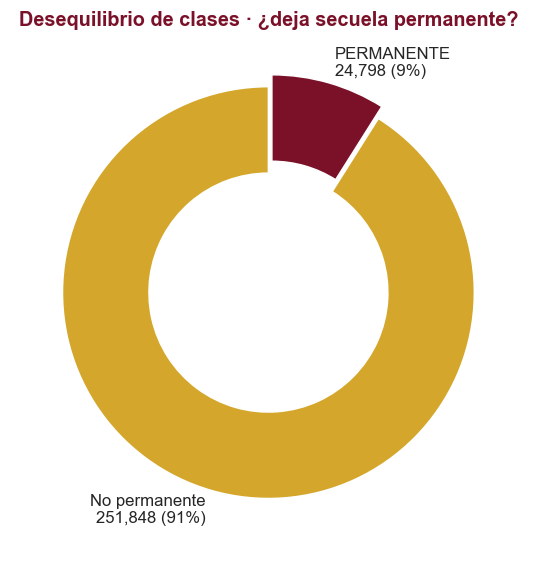

Un modelo que SIEMPRE diga 'no permanente' acertaría el 91% de las veces... y sería INÚTIL (recall = 0).
=> el accuracy MIENTE con datos desbalanceados. Métrica correcta: RECALL / F1.


In [14]:
conteo = df["PERMANENTE"].value_counts().sort_index()
labels = [f"No permanente\n{conteo[0]:,} ({conteo[0]/len(df)*100:.0f}%)",
          f"PERMANENTE\n{conteo[1]:,} ({conteo[1]/len(df)*100:.0f}%)"]

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.pie(conteo.values, labels=labels, colors=[DORADO, GRANATE], startangle=90,
       explode=(0, 0.06), wedgeprops=dict(width=0.42, edgecolor="white"),
       textprops=dict(fontsize=11))
ax.set_title("Desequilibrio de clases · ¿deja secuela permanente?")
plt.tight_layout(); plt.show()

print("Un modelo que SIEMPRE diga 'no permanente' acertaría el "
      f"{100*conteo[0]/len(df):.0f}% de las veces... y sería INÚTIL (recall = 0).")
print("=> el accuracy MIENTE con datos desbalanceados. Métrica correcta: RECALL / F1.")


### 3.4 · Análisis bivariado — ¿qué eleva el riesgo de secuela permanente?
Categórica vs. variable objetivo: la señal predictiva que aprenderá el modelo.


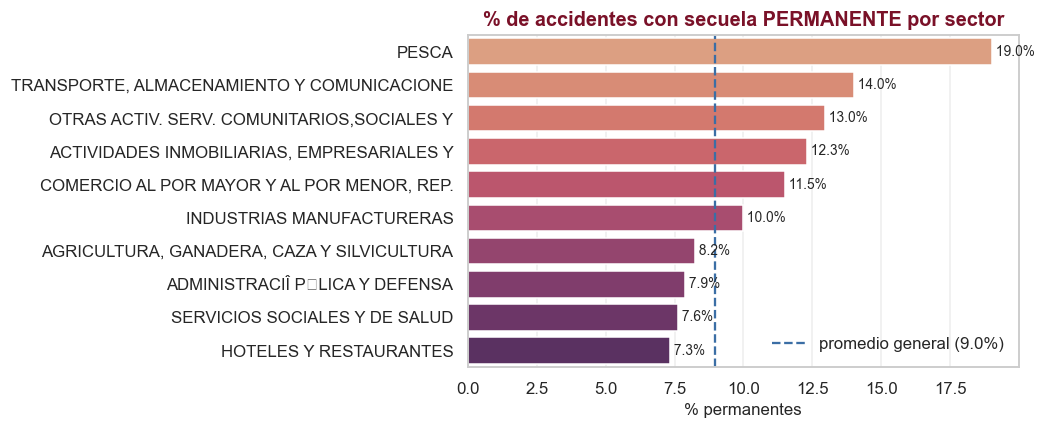

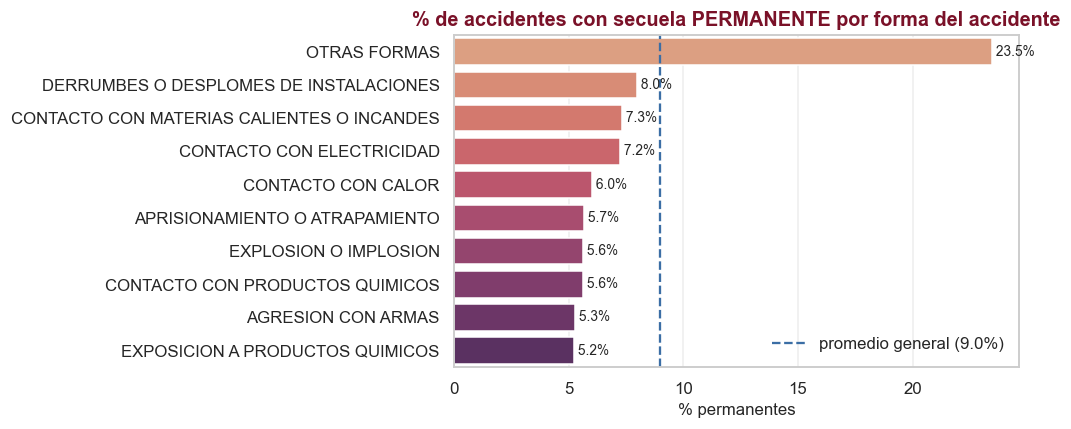

Hay señal predictiva clara: el sector y la forma del accidente discriminan la gravedad.
=> el modelo TIENE de dónde aprender (no estamos prediciendo ruido).


In [15]:
def tasa_por(col, min_n=500, top=10):
    g = df.groupby(col)["PERMANENTE"].agg(["mean", "count"])
    g = g[g["count"] >= min_n].sort_values("mean", ascending=False).head(top)
    g["mean"] *= 100
    return g

for col, titulo in [("ACTIVIDAD_ECONOMICA", "% de accidentes con secuela PERMANENTE por sector"),
                    ("FORMA_DEL_ACCIDENTE", "% de accidentes con secuela PERMANENTE por forma del accidente")]:
    g = tasa_por(col)
    fig, ax = plt.subplots(figsize=(9.5, 4))
    sns.barplot(x=g["mean"].values, y=[str(i)[:42] for i in g.index], ax=ax, palette="flare")
    ax.axvline(df["PERMANENTE"].mean()*100, color=AZUL, ls="--", lw=1.5,
               label=f"promedio general ({df['PERMANENTE'].mean()*100:.1f}%)")
    ax.set_title(titulo); ax.set_xlabel("% permanentes"); ax.set_ylabel(""); ax.legend()
    for i, v in enumerate(g["mean"].values):
        ax.text(v, i, f" {v:.1f}%", va="center", fontsize=9)
    plt.tight_layout(); plt.show()

print("Hay señal predictiva clara: el sector y la forma del accidente discriminan la gravedad.")
print("=> el modelo TIENE de dónde aprender (no estamos prediciendo ruido).")


In [16]:
# Tabla de contingencia: sexo × target
cont = pd.crosstab(df["SEXO"], df["PERMANENTE"], normalize="index") * 100
cont.columns = ["% No permanente", "% Permanente"]
display(cont.style.background_gradient(subset=["% Permanente"], cmap="Reds").format("{:.1f}%"))
print("Nota: las 4 categorías son en realidad 2 (problema de consistencia ya detectado).")


,% No permanente,% Permanente
SEXO,,
FEMENINO,99.8%,0.2%
HOMBRE,89.1%,10.9%
MASCULINO,99.7%,0.3%
MUJER,88.8%,11.2%


Nota: las 4 categorías son en realidad 2 (problema de consistencia ya detectado).


### 3.5 · Variación temporal
Serie mensual de accidentes: tendencia, estacionalidad y el **quiebre estructural por COVID (2020)**.


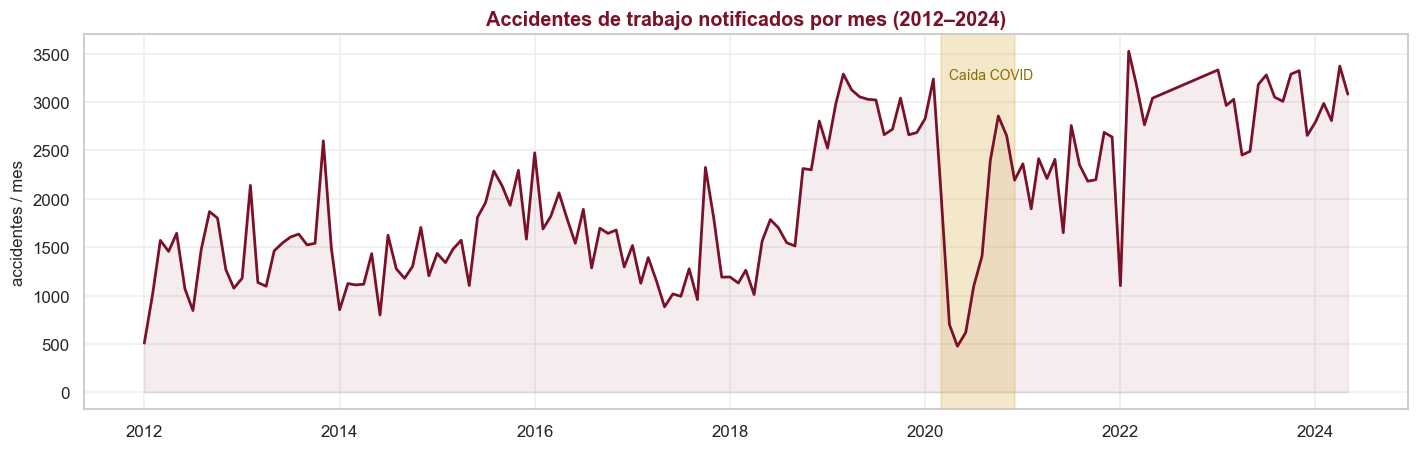

Meses: 142 | media: 1948/mes | mín: 477 | máx: 3525
→ El escalón COVID debe tratarse en el Panel 3 (excluir 2020, marcarlo o usar variable dummy),
  de lo contrario el modelo de pronóstico aprenderá una caída que no se repetirá.


In [17]:
MES_NUM = {"ENERO":1,"FEBRERO":2,"MARZO":3,"ABRIL":4,"MAYO":5,"JUNIO":6,"JULIO":7,
           "AGOSTO":8,"SETIEMBRE":9,"SEPTIEMBRE":9,"OCTUBRE":10,"NOVIEMBRE":11,"DICIEMBRE":12}

tmp = df.dropna(subset=["ANIOS"]).copy()
tmp["MES_N"] = tmp["MES"].astype(str).str.upper().str.strip().map(MES_NUM)   # ← unifica las 24 variantes
tmp = tmp.dropna(subset=["MES_N"])
tmp["PERIODO"] = pd.to_datetime(dict(year=tmp["ANIOS"].astype(int),
                                     month=tmp["MES_N"].astype(int), day=1))

serie = tmp.groupby("PERIODO").size()

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(serie.index, serie.values, color=GRANATE, lw=1.8)
ax.fill_between(serie.index, serie.values, color=GRANATE, alpha=0.08)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-12-01"), color=DORADO, alpha=0.25)
ax.text(pd.Timestamp("2020-04-01"), serie.max()*0.92, "Caída COVID", color="#8a6d00", fontsize=9)
ax.set_title("Accidentes de trabajo notificados por mes (2012–2024)")
ax.set_ylabel("accidentes / mes"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

print(f"Meses: {len(serie)} | media: {serie.mean():.0f}/mes | mín: {serie.min()} | máx: {serie.max()}")
print("→ El escalón COVID debe tratarse en el Panel 3 (excluir 2020, marcarlo o usar variable dummy),")
print("  de lo contrario el modelo de pronóstico aprenderá una caída que no se repetirá.")


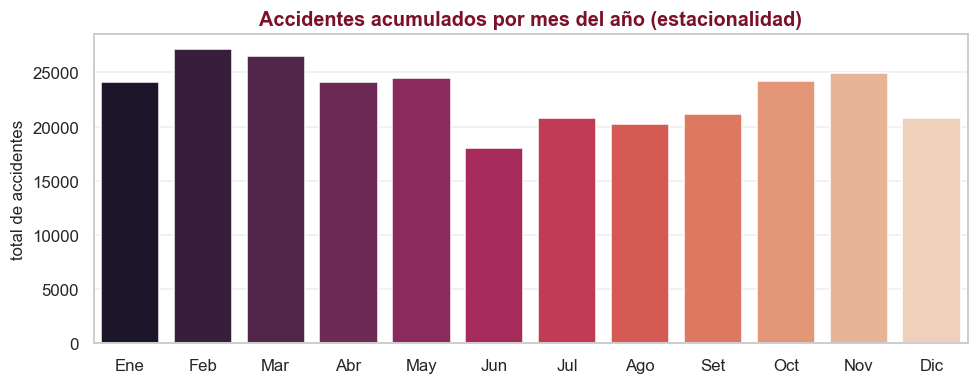

In [18]:
# Estacionalidad: ¿hay meses más peligrosos?
est = tmp.groupby("MES_N").size()
fig, ax = plt.subplots(figsize=(9, 3.6))
sns.barplot(x=est.index, y=est.values, ax=ax, palette="rocket")
ax.set_xticklabels(["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Set","Oct","Nov","Dic"])
ax.set_title("Accidentes acumulados por mes del año (estacionalidad)")
ax.set_xlabel(""); ax.set_ylabel("total de accidentes")
plt.tight_layout(); plt.show()


### 3.6 · Valores faltantes (Missing Values)
El **mecanismo** que los genera determina cómo tratarlos: **MCAR · MAR · MNAR**.


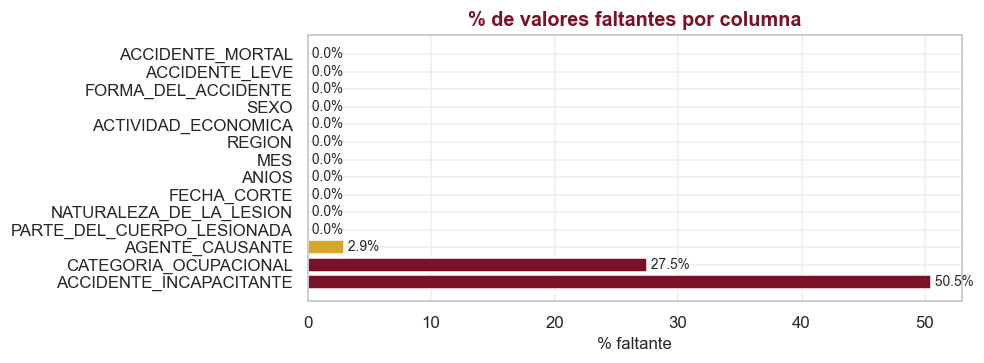

,% nulos
ACCIDENTE_INCAPACITANTE,50.46
CATEGORIA_OCUPACIONAL,27.49
AGENTE_CAUSANTE,2.95
PARTE_DEL_CUERPO_LESIONADA,0.00
NATURALEZA_DE_LA_LESION,0.00
FECHA_CORTE,0.00
ANIOS,0.00
MES,0.00
REGION,0.00
ACTIVIDAD_ECONOMICA,0.00


In [19]:
falt = (df.isna().mean() * 100).sort_values(ascending=False)
falt = falt[falt > 0]

fig, ax = plt.subplots(figsize=(9, 3.4))
bars = ax.barh(falt.index, falt.values, color=[GRANATE if v > 10 else DORADO for v in falt.values])
ax.set_title("% de valores faltantes por columna")
ax.set_xlabel("% faltante")
for b, v in zip(bars, falt.values):
    ax.text(v, b.get_y()+b.get_height()/2, f" {v:.1f}%", va="center", fontsize=9)
plt.tight_layout(); plt.show()
display(falt.round(2).to_frame("% nulos"))


**Diagnóstico del mecanismo:**

| Columna | % nulo | Mecanismo probable | Tratamiento (Fase 3) |
|---|---|---|---|
| `ACCIDENTE_INCAPACITANTE` | ~50% | **Estructural, NO es un error** — está vacío justo cuando el accidente fue *leve*. El "faltante" **es** información. | No imputar: es la definición del target |
| `CATEGORIA_OCUPACIONAL` | ~27% | **MAR** — depende de qué empresa/año reportó, no del valor ausente | Imputar por moda **o** crear categoría *"Desconocido"* |
| `AGENTE_CAUSANTE` | ~3% | MAR / MCAR | Imputar por moda o *"Desconocido"* |

> 💡 **Insight clave:** el 50% de nulos en `ACCIDENTE_INCAPACITANTE` **no es un problema de calidad** —
> es cómo el sistema codifica "accidente leve". Confundirlo con un error y borrar esas filas
> destruiría la mitad del dataset. *Comprender los datos evita esa catástrofe.*


### 3.7 · Outliers
El dataset es **casi enteramente categórico**: la única numérica real es el **conteo de accidentes por mes**
(la serie del Panel 3). Ahí sí aplicamos la regla **1.5·IQR**.


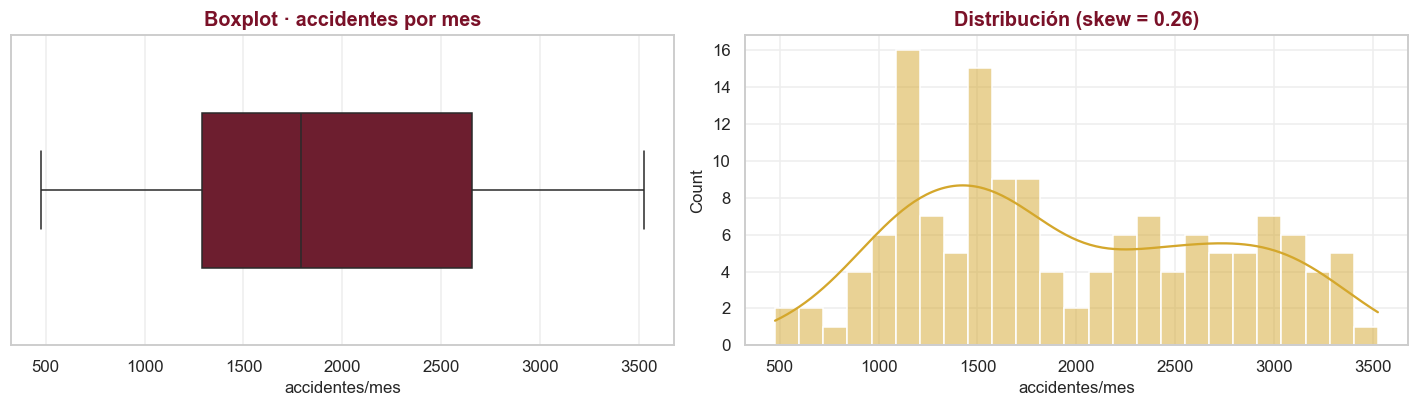

Q1=1288  Q3=2655  IQR=1366  | límites: [-761, 4704]
Outliers detectados: 0

Decisión informada: NO se eliminan. Corresponden a los meses de la pandemia —
son un EVENTO REAL, no un error de medición. Se tratan como quiebre estructural en el Panel 3.


In [20]:
q1, q3 = serie.quantile(.25), serie.quantile(.75)
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = serie[(serie < lim_inf) | (serie > lim_sup)]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
sns.boxplot(x=serie.values, color=GRANATE, ax=axes[0], width=0.5)
axes[0].set_title("Boxplot · accidentes por mes"); axes[0].set_xlabel("accidentes/mes")
sns.histplot(serie.values, bins=25, kde=True, color=DORADO, ax=axes[1], edgecolor="white")
axes[1].set_title(f"Distribución (skew = {serie.skew():.2f})"); axes[1].set_xlabel("accidentes/mes")
plt.tight_layout(); plt.show()

print(f"Q1={q1:.0f}  Q3={q3:.0f}  IQR={iqr:.0f}  | límites: [{lim_inf:.0f}, {lim_sup:.0f}]")
print(f"Outliers detectados: {len(outliers)}")
if len(outliers):
    print(outliers.to_string())
print("\nDecisión informada: NO se eliminan. Corresponden a los meses de la pandemia —")
print("son un EVENTO REAL, no un error de medición. Se tratan como quiebre estructural en el Panel 3.")


---
## ✅ Etapa 4 — Verificación de Calidad: las 8 dimensiones
La tabla-auditoría que va directo al reporte.


In [21]:
n = len(df)
audit = [
 ["1. Exactitud", "¿Los valores reflejan la realidad?",
  "Son notificaciones auto-reportadas por la empresa; posible subregistro (informalidad). No verificable con fuente externa.", "⚠️"],
 ["2. Completitud", "Ausencia de valores nulos",
  f"CATEGORIA_OCUPACIONAL {df['CATEGORIA_OCUPACIONAL'].isna().mean()*100:.0f}% nulo · AGENTE_CAUSANTE {df['AGENTE_CAUSANTE'].isna().mean()*100:.0f}% · (INCAPACITANTE 50% = estructural, no error)", "⚠️"],
 ["3. Consistencia", "Misma codificación para el mismo concepto",
  f"MES={df['MES'].nunique()} valores (debería ser 12: ENERO vs Enero) · SEXO={df['SEXO'].nunique()} (HOMBRE=MASCULINO) · encabezados corruptos por latin-1", "🔴"],
 ["4. Integridad", "Coherencia entre variables relacionadas",
  "LEVE / INCAPACITANTE / MORTAL son mutuamente coherentes; sin registros en dos clases a la vez", "✅"],
 ["5. Razonabilidad", "¿Los valores tienen sentido?",
  "Caída fuerte de notificaciones en 2020 → coherente con la pandemia, NO es un error", "✅"],
 ["6. Oportunidad", "Vigencia temporal",
  f"{int(df['ANIOS'].min())}–{int(df['ANIOS'].max())} ({df.groupby(['ANIOS','MES']).ngroups} periodos); corte jul-2024", "✅"],
 ["7. Unicidad", "Ausencia de duplicados",
  f"{df.duplicated().sum():,} filas 100% duplicadas ({df.duplicated().mean()*100:.1f}%) — probables accidentes distintos con mismos atributos", "⚠️"],
 ["8. Validez", "Valores dentro del dominio permitido",
  f"FECHA_CORTE constante (sin varianza) · {int(df['ANIOS'].isna().sum())} fila(s) sin año · MES en texto, no numérico", "⚠️"],
]
tabla8 = pd.DataFrame(audit, columns=["Dimensión", "Qué se revisó", "Hallazgo", "Estado"])
display(tabla8.style.hide(axis="index").set_properties(**{"text-align": "left"}))


Dimensión,Qué se revisó,Hallazgo,Estado
1. Exactitud,¿Los valores reflejan la realidad?,Son notificaciones auto-reportadas por la empresa; posible subregistro (informalidad). No verificable con fuente externa.,⚠️
2. Completitud,Ausencia de valores nulos,"CATEGORIA_OCUPACIONAL 27% nulo · AGENTE_CAUSANTE 3% · (INCAPACITANTE 50% = estructural, no error)",⚠️
3. Consistencia,Misma codificación para el mismo concepto,MES=24 valores (debería ser 12: ENERO vs Enero) · SEXO=4 (HOMBRE=MASCULINO) · encabezados corruptos por latin-1,🔴
4. Integridad,Coherencia entre variables relacionadas,LEVE / INCAPACITANTE / MORTAL son mutuamente coherentes; sin registros en dos clases a la vez,✅
5. Razonabilidad,¿Los valores tienen sentido?,"Caída fuerte de notificaciones en 2020 → coherente con la pandemia, NO es un error",✅
6. Oportunidad,Vigencia temporal,2012–2024 (142 periodos); corte jul-2024,✅
7. Unicidad,Ausencia de duplicados,"36,814 filas 100% duplicadas (13.3%) — probables accidentes distintos con mismos atributos",⚠️
8. Validez,Valores dentro del dominio permitido,"FECHA_CORTE constante (sin varianza) · 1 fila(s) sin año · MES en texto, no numérico",⚠️


---
## 🧾 Conclusiones de la Fase 2

**Los datos son ricos y reales (276,646 accidentes, 142 meses), pero sucios en 4 frentes:**

1. **Consistencia (🔴 crítico):** el mismo concepto escrito de varias formas —
   `MES` con **24** categorías en vez de 12 (`ENERO` vs `Enero`), `SEXO` con **4** en vez de 2
   (`HOMBRE`=`MASCULINO`), encabezados corrompidos por leer latin-1 como UTF-8,
   y `LIMA` conviviendo con `LIMA METROPOLITANA`.
   → *Es la lección "la tabla mentía" en datos reales.* Sin corregirlo, el modelo trataría
   `ENERO` y `Enero` como meses distintos.
2. **Completitud:** `CATEGORIA_OCUPACIONAL` ~27% nulo (MAR) → imputar o marcar *"Desconocido"*.
   El 50% de `ACCIDENTE_INCAPACITANTE` **NO es un error**: es cómo se codifica "leve".
3. **Alta cardinalidad:** 66 partes del cuerpo, 49 agentes causantes → agrupar antes de codificar.
4. **Quiebre estructural (COVID-2020):** real, no un outlier de medición → tratarlo en el pronóstico.

**Sobre el modelado:**
- El target **"secuela permanente"** queda **~9% / 91%** → desbalance 1:10 → **SMOTE / class_weight**,
  y la métrica correcta es **recall**, no accuracy.
- Hay **señal predictiva clara**: el sector económico y la forma del accidente discriminan la gravedad.
- Se **excluyen deliberadamente** `NATURALEZA_DE_LA_LESION` y `PARTE_DEL_CUERPO_LESIONADA`
  para evitar ***data leakage***: describen la consecuencia, no la causa. Así el modelo sirve para
  **prevenir**, no solo para describir lo ya ocurrido.

> **Ninguno de estos problemas invalida el proyecto.** Todos son tratables en la **Fase 3 (Preparación)**
> y son la materia prima de la narrativa *complicación → resolución* del reporte.

### ➡️ Siguiente: Fase 3 — Preparación
Selección · Limpieza · Construcción (features) · Integración · Formateo (Z-Score, One-Hot, VIF > 10)
